# RetailPulse AI Retail Analytics

## Notebook 7 : Inventory Optimization

### Objectives

- Load sales forecast
- Calculate demand
- Calculate safety stock
- Calculate reorder point
- Generate inventory recommendations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
forecast = pd.read_csv("../data/sales_forecast.csv")

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-01,23366.346113,32711.521109,64446.683783,23366.346113,23366.346113,25945.697892,25945.697892,25945.697892,8263.268564,8263.268564,8263.268564,17682.429328,17682.429328,17682.429328,0.0,0.0,0.0,49312.044006
1,2009-12-02,23362.918625,31164.162350,62448.395598,23362.918625,23362.918625,22892.261038,22892.261038,22892.261038,5364.460059,5364.460059,5364.460059,17527.800979,17527.800979,17527.800979,0.0,0.0,0.0,46255.179662
2,2009-12-03,23359.491136,38716.961348,68709.798255,23359.491136,23359.491136,29838.081810,29838.081810,29838.081810,12589.557409,12589.557409,12589.557409,17248.524401,17248.524401,17248.524401,0.0,0.0,0.0,53197.572945
3,2009-12-04,23356.063647,28944.659760,57794.962526,23356.063647,23356.063647,20397.315568,20397.315568,20397.315568,3563.249747,3563.249747,3563.249747,16834.065822,16834.065822,16834.065822,0.0,0.0,0.0,43753.379215
4,2009-12-05,23352.636158,-5606.768370,24206.962896,23352.636158,23352.636158,-13190.713874,-13190.713874,-13190.713874,-29467.137379,-29467.137379,-29467.137379,16276.423505,16276.423505,16276.423505,0.0,0.0,0.0,10161.922284


In [3]:
future_sales = forecast.tail(30).copy()

future_sales.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
604,2011-12-10,26625.276397,-6908.576065,24177.738781,26625.276397,26625.276397,-17533.161734,-17533.161734,-17533.161734,-29467.137379,-29467.137379,-29467.137379,11933.975645,11933.975645,11933.975645,0.0,0.0,0.0,9092.114663
605,2011-12-11,26643.281276,14934.315258,47057.179939,26643.281276,26643.281276,4634.846423,4634.846423,4634.846423,-5950.734482,-5950.734482,-5950.734482,10585.580905,10585.580905,10585.580905,0.0,0.0,0.0,31278.127698
606,2011-12-12,26661.286154,25525.542389,56979.833764,26661.286154,26661.286154,14757.742558,14757.742558,14757.742558,5637.336083,5637.336083,5637.336083,9120.406475,9120.406475,9120.406475,0.0,0.0,0.0,41419.028712
607,2011-12-13,26679.291032,27051.866660,58572.452934,26679.291032,26679.291032,15818.266370,15818.266370,15818.266370,8263.268564,8263.268564,8263.268564,7554.997806,7554.997806,7554.997806,0.0,0.0,0.0,42497.557403
608,2011-12-14,26697.295911,22473.201420,53588.865023,26697.295911,26697.295911,11273.184898,11273.184898,11273.184898,5364.460059,5364.460059,5364.460059,5908.724839,5908.724839,5908.724839,0.0,0.0,0.0,37970.480809


In [4]:
future_sales = future_sales[
    ["ds","yhat","yhat_lower","yhat_upper"]
]

future_sales.head()

,ds,yhat,yhat_lower,yhat_upper
604,2011-12-10,9092.114663,-6908.576065,24177.738781
605,2011-12-11,31278.127698,14934.315258,47057.179939
606,2011-12-12,41419.028712,25525.542389,56979.833764
607,2011-12-13,42497.557403,27051.866660,58572.452934
608,2011-12-14,37970.480809,22473.201420,53588.865023


In [5]:
future_sales.columns = [
    "Date",
    "Forecast",
    "Lower",
    "Upper"
]

future_sales.head()

,Date,Forecast,Lower,Upper
604,2011-12-10,9092.114663,-6908.576065,24177.738781
605,2011-12-11,31278.127698,14934.315258,47057.179939
606,2011-12-12,41419.028712,25525.542389,56979.833764
607,2011-12-13,42497.557403,27051.866660,58572.452934
608,2011-12-14,37970.480809,22473.201420,53588.865023


In [6]:
future_sales["Forecast"] = future_sales["Forecast"].clip(lower=0)

In [8]:
#Safety Stock = Upper Forecast − Forecast
future_sales["Safety_Stock"] = (
    future_sales["Upper"] -
    future_sales["Forecast"]
)

future_sales.head()

,Date,Forecast,Lower,Upper,Safety_Stock
604,2011-12-10,9092.114663,-6908.576065,24177.738781,15085.624118
605,2011-12-11,31278.127698,14934.315258,47057.179939,15779.052241
606,2011-12-12,41419.028712,25525.542389,56979.833764,15560.805052
607,2011-12-13,42497.557403,27051.866660,58572.452934,16074.895531
608,2011-12-14,37970.480809,22473.201420,53588.865023,15618.384214


In [11]:
# Assume lead time is 7 days
lead_time = 7

future_sales["Reorder_Point"] = (
    future_sales["Forecast"] +
    future_sales["Safety_Stock"]
)

In [12]:
future_sales["Recommended_Stock"] = (
    future_sales["Reorder_Point"] * 1.10
)

In [13]:
future_sales.head(10)

,Date,Forecast,Lower,Upper,Safety_Stock,Reorder_Point,Recommended_Stock
604,2011-12-10,9092.114663,-6908.576065,24177.738781,15085.624118,24177.738781,26595.512659
605,2011-12-11,31278.127698,14934.315258,47057.179939,15779.052241,47057.179939,51762.897933
606,2011-12-12,41419.028712,25525.542389,56979.833764,15560.805052,56979.833764,62677.817140
607,2011-12-13,42497.557403,27051.866660,58572.452934,16074.895531,58572.452934,64429.698228
608,2011-12-14,37970.480809,22473.201420,53588.865023,15618.384214,53588.865023,58947.751525
609,2011-12-15,43508.254090,28174.401913,59056.959413,15548.705323,59056.959413,64962.655354
610,2011-12-16,32759.353603,17390.288548,48363.189039,15603.835436,48363.189039,53199.507943
611,2011-12-17,0.000000,-17651.809182,13981.589454,13981.589454,13981.589454,15379.748399
612,2011-12-18,19796.242406,4718.958024,35355.029823,15558.787417,35355.029823,38890.532806
613,2011-12-19,29710.323255,14089.741912,45427.532876,15717.209621,45427.532876,49970.286163


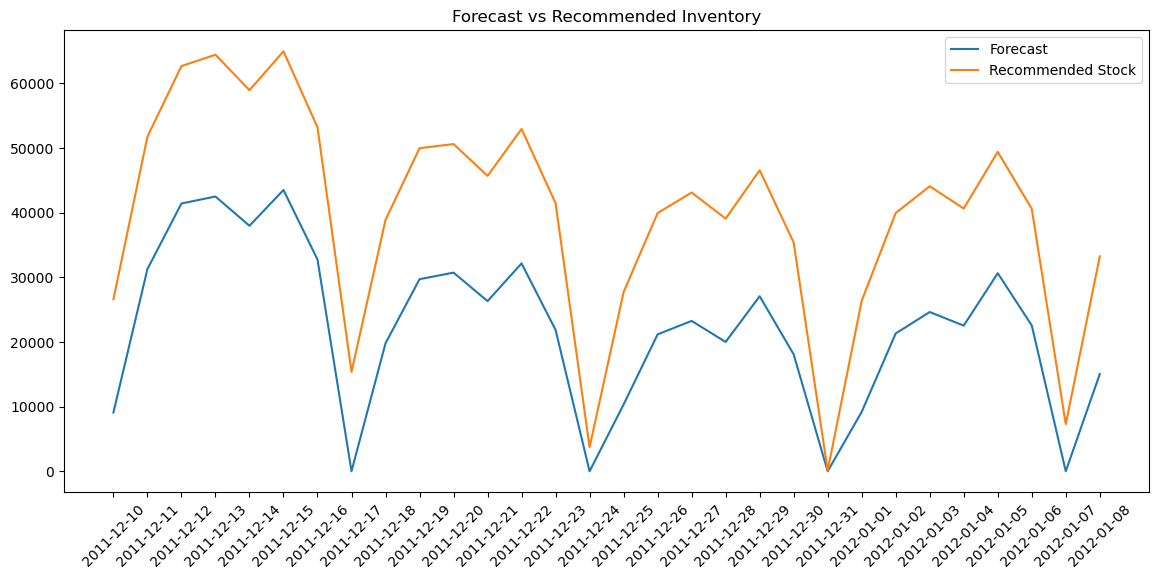

In [14]:
plt.figure(figsize=(14,6))

plt.plot(
    future_sales["Date"],
    future_sales["Forecast"],
    label="Forecast"
)

plt.plot(
    future_sales["Date"],
    future_sales["Recommended_Stock"],
    label="Recommended Stock"
)

plt.xticks(rotation=45)

plt.legend()

plt.title("Forecast vs Recommended Inventory")

plt.show()

In [15]:
print(
    "Average Recommended Stock :",
    future_sales["Recommended_Stock"].mean()
)

Average Recommended Stock : 39824.6387421079


In [16]:
future_sales.to_csv(
    "../data/inventory_recommendation.csv",
    index=False
)

# Business Insights

The inventory optimization module recommends future stock levels based on forecasted demand.

Business Benefits

- Prevent stock-outs
- Reduce excess inventory
- Improve warehouse utilization
- Reduce inventory cost
- Improve customer satisfaction